# 3 — Paper figures

Builds the three main figures and their accompanying statistics tables.

| | |
|---|---|
| **Figure 1** | Pipeline schematic for one example scene |
| **Figure 2** | Violin comparison: per-image corr(AIMM, HMM) across VLMs and DeepMeaning training sets |
| **Figure 3** | Fixation-correlation overview: AIMM, HMM, DMM, GBVS, AWS, DGIIE |

Map shorthands used throughout: **AIMM** = zero-shot VLM meaning map,
**HMM** = human meaning map, **DMM** = DeepMeaning map, **GBVS** = Graph-Based Visual Saliency, **AWS** = Adaptive Whitening Saliency, **DGIIE** = DeepGaze IIE.

Figures are written to `results/paper_plots/`. Supplementary figures live in
`4_supplementary_plots.ipynb`.

In [1]:
%load_ext autoreload
%autoreload 2

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.map_comparison import SaliencyComparator
from src.paper_plots import MultiDatasetPlotter
from src.stats_utils import (
    r2z, mean_r_ci, fmt_p, clean_style, second_order_stats, fdr_bh,
)

## Configuration

In [2]:
# --- Datasets (order sets the x-axis order) ---------------------------------
DATASETS = ["P21_scegram", "HH25_indoor", "HH25_outdoor"]

DATASET_COLORS = {
    "P21_scegram":  "#e67c73",
    "HH25_indoor":  "#7baaf7",
    "HH25_outdoor": "#96CEB4",
}

DATASET_LABELS = {
    "P21_scegram":  "P21-scegram",
    "HH25_indoor":  "HH25-indoor",
    "HH25_outdoor": "HH25-outdoor",
}

# Center-bias condition per dataset: 'ncb' = none, 'cb' = center bias applied.
DATASET_BIAS = {
    "P21_scegram":  "ncb",
    "HH25_indoor":  "ncb",
    "HH25_outdoor": "ncb",
}

# --- Smoothing --------------------------------------------------------------
# The two figures deliberately use different settings:
#   Figure 2 - none. AIMM and HMM are patch-reconstructed at the same resolution.
#   Figure 3 - sigma=15 replicates Hayes & Henderson (2025), applied only to the
#              meaning-style maps. Fixation maps are pre-smoothed density
#              estimates and GBVS/AWS/DGIIE are already smooth, so both are excluded.
FIG2_SMOOTHING_SIGMA        = None
FIG2_EXCLUDE_FROM_SMOOTHING = []

FIG3_SMOOTHING_SIGMA        = 15
FIG3_EXCLUDE_FROM_SMOOTHING = ["fixation", "gbvs", "aws", "deepgaze"]

# --- Histogram matching -----------------------------------------------------
# Maps listed in EXCLUDE_FROM_MATCHING keep their own histogram.
HISTOGRAM_MATCH       = False
MATCHING_REFERENCE    = "deepgaze"
EXCLUDE_FROM_MATCHING = ["fixation"]

print("Datasets:", DATASETS)
print("Bias:    ", {ds: DATASET_BIAS[ds] for ds in DATASETS})
print(f"Smoothing: Fig 2 sigma={FIG2_SMOOTHING_SIGMA} (excl. {FIG2_EXCLUDE_FROM_SMOOTHING}) | "
      f"Fig 3 sigma={FIG3_SMOOTHING_SIGMA} (excl. {FIG3_EXCLUDE_FROM_SMOOTHING})")

Datasets: ['P21_scegram', 'HH25_indoor', 'HH25_outdoor']
Bias:     {'P21_scegram': 'ncb', 'HH25_indoor': 'ncb', 'HH25_outdoor': 'ncb'}
Smoothing: Fig 2 sigma=None (excl. []) | Fig 3 sigma=15 (excl. ['fixation', 'gbvs', 'aws', 'deepgaze'])


In [3]:
# --- Models -----------------------------------------------------------------
# Figure 2: whose per-dataset median is drawn as the reference line (must be in
# MODELS_FIG2_VLM). Figure 3: whose AIMM maps are loaded.
fig2_model     = "google/gemini-3-flash-preview"
fig2_prompt_id = "original"

fig3_model     = "google/gemma-4-31b-it"
fig3_prompt_id = "original"

fig2_model_slug            = fig2_model.split("/")[-1]
fig3_model_slug            = fig3_model.split("/")[-1]
fig3_model_slug_and_prompt = f"{fig3_model_slug}_{fig3_prompt_id}/"

# --- DeepMeaning maps -------------------------------------------------------
# Laid out as {trained}__to__{applied}/maps_combined_raw, named by the *applied*
# dataset's scenes. DM_DATASET_TOKEN maps repo dataset names to folder tokens.
DEEPMEANING_ROOT = "results/DeepMeaning"
DM_DATASET_TOKEN = {
    "P21_scegram":  "p21_128",
    "HH25_indoor":  "hh25_indoor",
    "HH25_outdoor": "hh25_outdoor",
}

# --- Output -----------------------------------------------------------------
publication_output = "results/paper_plots/"
os.makedirs(publication_output, exist_ok=True)

print(f"Fig 2 reference model : {fig2_model_slug} ({fig2_prompt_id})")
print(f"Fig 3 model           : {fig3_model_slug} ({fig3_prompt_id})")
print(f"Output dir            : {publication_output}")

Fig 2 reference model : gemini-3-flash-preview (original)
Fig 3 model           : gemma-4-31b-it (original)
Output dir            : results/paper_plots/


### Figure sizing

`FIG_WIDTH_MM` is maximum width. Figure 2 uses it exactly; Figure 3
is deliberately narrower because its B/C panels are `aspect='equal'` squares, 
and stretching the canvas only widens the gaps between them. 
Maximum height for either figure is ~270 mm.

- Figure 3 panel sizes are given in millimetres and the figure height is *derived*
  from them, so adding a model or dataset changes the canvas, not the proportions.
- Figures are saved without `bbox_inches="tight"`, which would re-trim and
  change the final size. Layout is fitted inside the canvas instead.
- All text sizes derive from `BASE_FONTSIZE`.

In [4]:
# === Journal figure sizing (single source of truth) ==========================
MM_PER_INCH  = 25.4
FIG_WIDTH_MM = 190.0                        # journal-required fixed width (edit here)
FIG_WIDTH_IN = FIG_WIDTH_MM / MM_PER_INCH

def mm_to_in(mm):
    return mm / MM_PER_INCH

# Base font size (pt) at final print size. BOTH figures use this same base so
# text is visually consistent between them (Fig 3 receives it via base_fontsize,
# Fig 2 via the rcParams below). Change it in one place to rescale everything.
BASE_FONTSIZE = 7

# Shared dot sizes (points^2) so markers match across Fig 2 and Fig 3.
# Fig 2 uses the first two; Fig 3 receives all four via plot_fixation_correlation_grid(...).
DOT_INDIVIDUAL    = 9    # jittered per-image dots (violin panels, both figures)
DOT_GROUP         = 22   # median marker (violin panels, both figures)
DOT_SCATTER       = 10   # Fig 3 column B single scatter
DOT_SCATTER_SMALL = 6    # Fig 3 column C scatter grid

plt.rcParams.update({
    "savefig.dpi":      500,
    "figure.dpi":       500,
    "font.size":        BASE_FONTSIZE+2,
    "axes.titlesize":   BASE_FONTSIZE+2,
    "axes.labelsize":   BASE_FONTSIZE+2,
    "xtick.labelsize":  BASE_FONTSIZE+2,   # match Fig 3 (which uses base for ticks)
    "ytick.labelsize":  BASE_FONTSIZE+2,
    "legend.fontsize":  BASE_FONTSIZE+2,
    "figure.titlesize": BASE_FONTSIZE + 2,
    "savefig.bbox":     None,   # NEVER 'tight' — it would change the fixed width
})

print(f"Fixed figure width: {FIG_WIDTH_MM:.0f} mm = {FIG_WIDTH_IN:.3f} in")
print(f"Base font size    : {BASE_FONTSIZE} pt")

Fixed figure width: 190 mm = 7.480 in
Base font size    : 7 pt


## Figure 1 — Pipeline schematic

One example scene through the whole pipeline:

**A** scene image · **B** multi-scale patch coverage · **C** example patches sent
to the VLM · **D** per-scale reconstructed maps · **E** combined AI meaning map.

Rendered at the same width and DPI as Figures 2 and 3. Reusable helpers live in
`src/schematic_fig.py`.

In [5]:
# --- Figure 1 configuration -------------------------------------------------
# The middle column is a narrow vertical "Zero-Shot AI" box (violet, matching the
# Figure 2 block header) rather than the full prompt text, which keeps the figure
# within the journal column width.
from pathlib import Path

import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle, Rectangle
from PIL import Image

from src.schematic_fig import (
    read_patch_params, circular_patch, reconstruct_scene_map, patch_score,
)

FIG1_DATASET   = "P21_scegram"
FIG1_SCENE     = "Scene44_CON"
FIG1_IMAGE     = Path(f"data/{FIG1_DATASET}/images/{FIG1_SCENE}.png")
FIG1_CSV       = Path(f"data/{FIG1_DATASET}/{FIG1_DATASET}_patches_orig.csv")
FIG1_MODEL     = "google/gemma-4-31b-it"
FIG1_PROMPT_ID = "original"
FIG1_PARQUET   = Path(f"results/results_scores/results_{FIG1_DATASET}_{FIG1_PROMPT_ID}.parquet")

FIG1_FINE_R    = 53
FIG1_COARSE_R  = 123
FIG1_FINE_PATCH   = dict(x=489, y=291, r=FIG1_FINE_R)
FIG1_COARSE_PATCH = dict(x=393, y=214, r=FIG1_COARSE_R)

# Nine columns; 3 and 5 are the arrow spacers flanking the "Zero-Shot AI" box (col 4).
FIG1_COL_W = [1, 0.58, 0.30, 0.13, 0.34, 0.13, 0.14, 0.58, 1]

print("Figure 1 config ready.")

Figure 1 config ready.


In [6]:
# --- Figure 1: load scene, patches, reconstruct per-radius maps -------------
_fig1_img = Image.open(FIG1_IMAGE).convert("RGB")
FIG1_IMG_W, FIG1_IMG_H = _fig1_img.size

_fig1_params = read_patch_params(FIG1_CSV)
_fig1_df     = pd.read_parquet(FIG1_PARQUET)

_fig1_fine_map   = reconstruct_scene_map(_fig1_df, FIG1_SCENE, FIG1_MODEL, FIG1_PROMPT_ID, FIG1_FINE_R)
_fig1_coarse_map = reconstruct_scene_map(_fig1_df, FIG1_SCENE, FIG1_MODEL, FIG1_PROMPT_ID, FIG1_COARSE_R)
_fig1_comb_map   = np.nanmean(np.stack([_fig1_fine_map, _fig1_coarse_map]), axis=0).astype(np.float32)

# Shared grey scale across all three maps (original, unnormalised values).
FIG1_VMIN = float(min(np.nanmin(_fig1_fine_map), np.nanmin(_fig1_coarse_map)))
FIG1_VMAX = float(max(np.nanmax(_fig1_fine_map), np.nanmax(_fig1_coarse_map)))

_fig1_fine_patch   = circular_patch(_fig1_img, **FIG1_FINE_PATCH)
_fig1_coarse_patch = circular_patch(_fig1_img, **FIG1_COARSE_PATCH)

_fig1_fine_score   = patch_score(_fig1_df, FIG1_SCENE, **FIG1_FINE_PATCH)
_fig1_coarse_score = patch_score(_fig1_df, FIG1_SCENE, **FIG1_COARSE_PATCH)

print(f"Scene {FIG1_SCENE}: {FIG1_IMG_W}x{FIG1_IMG_H} | "
      f"scores fine={_fig1_fine_score} coarse={_fig1_coarse_score} | "
      f"map range {FIG1_VMIN:.2f}-{FIG1_VMAX:.2f}")

Scene Scene44_CON: 688x524 | scores fine=5 coarse=6 | map range 1.00-6.00


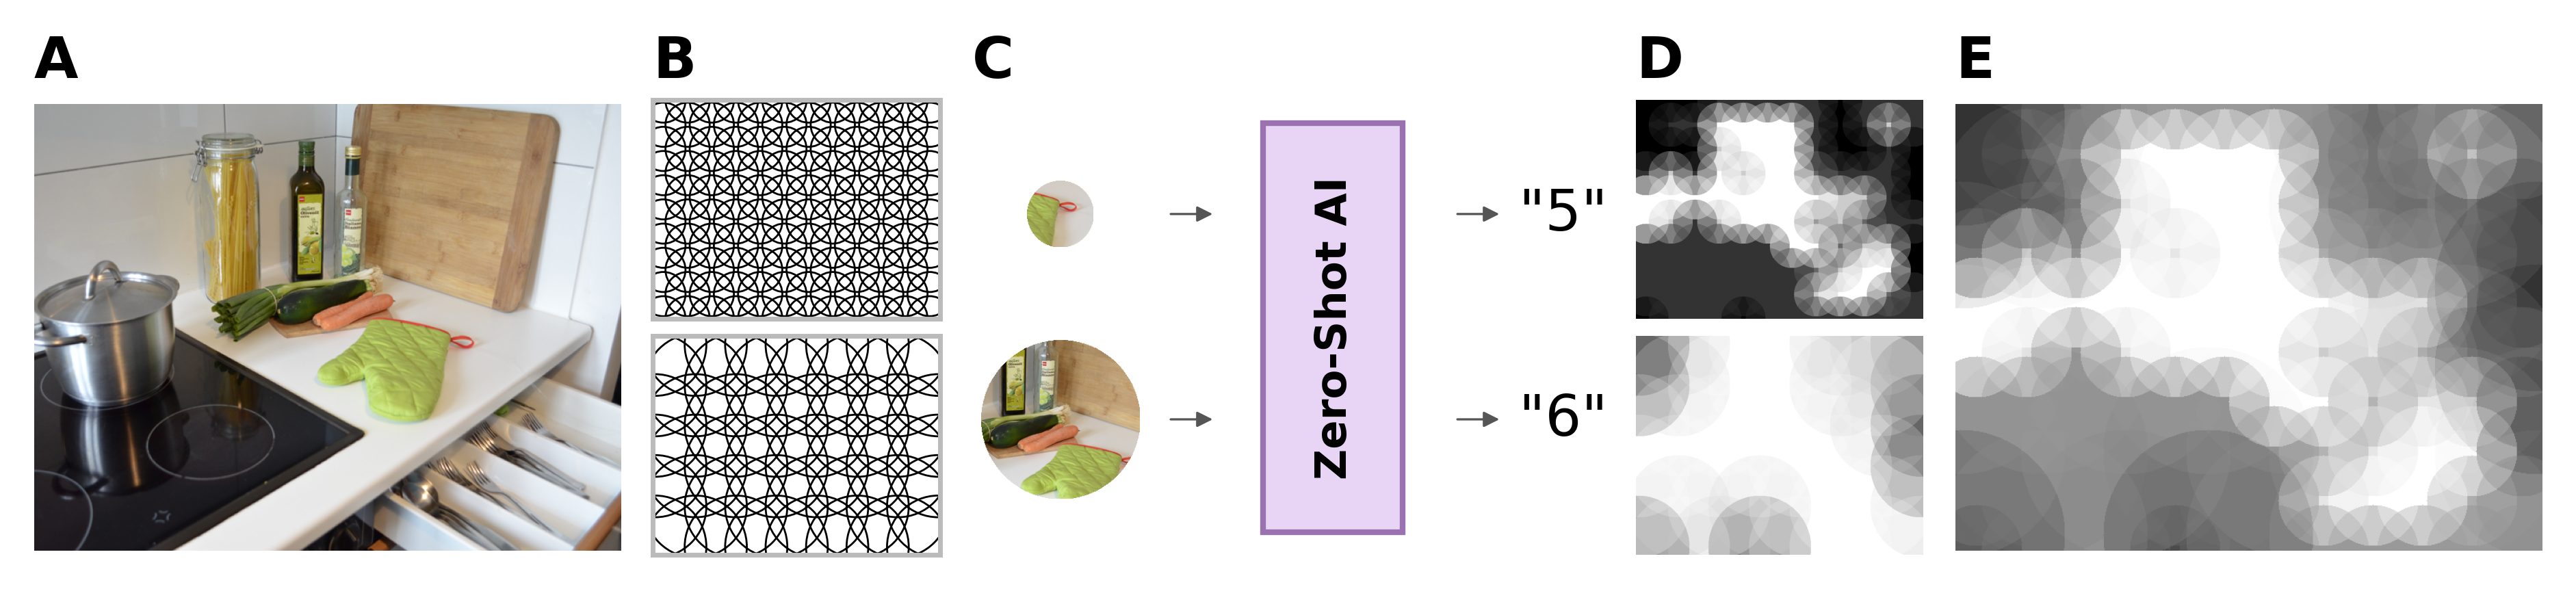

Saved -> results/paper_plots/fig1_schematic.png
Figure 1 size: 190.0 x 40.2 mm


In [7]:
# --- Figure 1: assemble the schematic (fixed width, high dpi, no tight bbox) -
FIG1_W = FIG_WIDTH_IN                        # same fixed journal width as Figs 2 & 3
SCALE  = FIG1_W / 24.0                       # arrow geometry scaled from the 24-in design

PATCH_TOP_PAD  = 20                          # blank rows above the two patch thumbnails
PLOT_L, PLOT_R = 0.01, 0.99
PLOT_B, PLOT_T = 0.02, 0.86                  # headroom above for the panel letters

# Figure height sized so the col-0 image fills the plotting area exactly.
_AR        = FIG1_IMG_H / FIG1_IMG_W
_col0_w_in = FIG1_W * (PLOT_R - PLOT_L) / sum(FIG1_COL_W)
FIG1_H     = (_col0_w_in * _AR) / (PLOT_T - PLOT_B)

# Per-patch display scales so the two thumbnails keep their true radius ratio.
_total_h    = FIG1_H * (PLOT_T - PLOT_B)
_col2_w     = _col0_w_in * FIG1_COL_W[2]
_hr_sum     = PATCH_TOP_PAD + FIG1_FINE_R + FIG1_COARSE_R
_fine_box   = min(_col2_w, _total_h * FIG1_FINE_R   / _hr_sum)
_coarse_box = min(_col2_w, _total_h * FIG1_COARSE_R / _hr_sum)
PS_COARSE   = 0.9
PS_FINE     = (FIG1_FINE_R / FIG1_COARSE_R) * (_coarse_box / _fine_box) * PS_COARSE

# Fonts: sized from the shared BASE_FONTSIZE and left in the notebook default
# (sans) family, so Fig 1 matches the font style of Figs 2 & 3 (no monospace).
FS_LETTER = BASE_FONTSIZE + 5                # panel letters A-E (bold)
FS_SCORE  = BASE_FONTSIZE + 5                # VLM score labels
FS_VLABEL = BASE_FONTSIZE + 2                # "Zero-Shot AI" (bold)
ARROW_MS  = 22 * SCALE
ARROW_LW  = 1.5 * SCALE

fig1 = plt.figure(figsize=(FIG1_W, FIG1_H), facecolor="white")
ogs = gridspec.GridSpec(1, 9, figure=fig1, width_ratios=FIG1_COL_W, wspace=0.02,
                        left=PLOT_L, right=PLOT_R, bottom=PLOT_B, top=PLOT_T)

def _grey_frame(ax, color="#BBBBBB", lw=1.0):
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color(color); sp.set_linewidth(lw)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# -- Col 0: original scene image ---------------------------------------------
ax_img = fig1.add_subplot(ogs[0, 0]); ax_img.imshow(_fig1_img); ax_img.axis("off")

# -- Col 1: patch coverage (fine top, coarse bottom) -------------------------
gs_cov = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=ogs[0, 1], hspace=0.08)
ax_cov_top = None
for i, r_val in enumerate([FIG1_FINE_R, FIG1_COARSE_R]):
    ax_c = fig1.add_subplot(gs_cov[i])
    if i == 0: ax_cov_top = ax_c
    ax_c.set_xlim(0, FIG1_IMG_W); ax_c.set_ylim(FIG1_IMG_H, 0)
    ax_c.set_aspect("equal", adjustable="box")
    for p in _fig1_params:
        if p["radius"] == r_val:
            ax_c.add_patch(Circle((p["xc"], p["yc"]), p["radius"],
                           fill=False, edgecolor="black", linewidth=0.4))
    _grey_frame(ax_c)

# -- Col 2: two selected patches (true size ratio) ---------------------------
gs_p = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=ogs[0, 2],
         height_ratios=[PATCH_TOP_PAD, FIG1_FINE_R, FIG1_COARSE_R], hspace=0.08)
ax_pad_c = fig1.add_subplot(gs_p[0]); ax_pad_c.axis("off")
for gi, patch_im, ps in [(1, _fig1_fine_patch, PS_FINE), (2, _fig1_coarse_patch, PS_COARSE)]:
    ax_p = fig1.add_subplot(gs_p[gi]); arr = np.array(patch_im)
    h, w = arr.shape[:2]; m = (1 - ps) / 2
    ax_p.imshow(arr, extent=[w*m, w*(1-m), h*(1-m), h*m])
    ax_p.set_xlim(0, w); ax_p.set_ylim(h, 0); ax_p.set_aspect("equal"); ax_p.axis("off")

# -- Col 3: arrows into the box ----------------------------------------------
gs_al = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=ogs[0, 3],
         height_ratios=[PATCH_TOP_PAD, FIG1_FINE_R, FIG1_COARSE_R], hspace=0.08)
for gi in (1, 2):
    ax_a = fig1.add_subplot(gs_al[gi]); ax_a.axis("off")
    ax_a.annotate("", xy=(0.9, 0.5), xytext=(0.1, 0.5),
        arrowprops=dict(arrowstyle="-|>", color="#555555", lw=ARROW_LW, mutation_scale=ARROW_MS),
        xycoords="axes fraction", textcoords="axes fraction")

# -- Col 4: large rectangular "Zero-Shot AI" box (violet fill + violet edge) --
ax_box = fig1.add_subplot(ogs[0, 4]); ax_box.axis("off")
ax_box.set_xlim(0, 1); ax_box.set_ylim(0, 1)
ax_box.add_patch(Rectangle((0.14, 0.05), 0.70, 0.90,
    linewidth=1.2, edgecolor="#9B72B0", facecolor="#E8D5F5",
    transform=ax_box.transAxes, clip_on=False))
ax_box.text(0.5, 0.5, "Zero-Shot AI", rotation=90, ha="center", va="center",
    fontsize=FS_VLABEL, fontweight="bold", color="#000000",
    transform=ax_box.transAxes)

# -- Col 5: arrows out of the box --------------------------------------------
gs_ar = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=ogs[0, 5],
         height_ratios=[PATCH_TOP_PAD, FIG1_FINE_R, FIG1_COARSE_R], hspace=0.08)
for gi in (1, 2):
    ax_a = fig1.add_subplot(gs_ar[gi]); ax_a.axis("off")
    ax_a.annotate("", xy=(0.9, 0.5), xytext=(0.1, 0.5),
        arrowprops=dict(arrowstyle="-|>", color="#555555", lw=ARROW_LW, mutation_scale=ARROW_MS),
        xycoords="axes fraction", textcoords="axes fraction")

# -- Col 6: VLM scores -------------------------------------------------------
gs_sc = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=ogs[0, 6],
         height_ratios=[PATCH_TOP_PAD, FIG1_FINE_R, FIG1_COARSE_R], hspace=0.08)
fig1.add_subplot(gs_sc[0]).axis("off")
for gi, score in [(1, _fig1_fine_score), (2, _fig1_coarse_score)]:
    ax_s = fig1.add_subplot(gs_sc[gi]); ax_s.axis("off")
    ax_s.text(0.5, 0.5, f'"{score}"', ha="center", va="center",
              fontsize=FS_SCORE, transform=ax_s.transAxes)

# -- Col 7: per-radius maps (shared grey scale) ------------------------------
gs_m = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=ogs[0, 7], hspace=0.08)
ax_map_top = None
for i, m in enumerate([_fig1_fine_map, _fig1_coarse_map]):
    ax_m = fig1.add_subplot(gs_m[i])
    if i == 0: ax_map_top = ax_m
    ax_m.imshow(np.nan_to_num(m, nan=FIG1_VMIN), cmap="gray", vmin=FIG1_VMIN, vmax=FIG1_VMAX)
    ax_m.axis("off")

# -- Col 8: combined map -----------------------------------------------------
ax_comb = fig1.add_subplot(ogs[0, 8])
ax_comb.imshow(np.nan_to_num(_fig1_comb_map, nan=FIG1_VMIN), cmap="gray",
               vmin=FIG1_VMIN, vmax=FIG1_VMAX)
ax_comb.axis("off")

# -- Panel letters A-E (shared baseline in figure fraction) ------------------
_ly = PLOT_T + 0.02
for ax_lbl, letter in [(ax_img, "A"), (ax_cov_top, "B"), (ax_pad_c, "C"),
                       (ax_map_top, "D"), (ax_comb, "E")]:
    fig1.text(ax_lbl.get_position().x0, _ly, letter, fontsize=FS_LETTER,
              fontweight="bold", va="bottom", ha="left")

# NOTE: save WITHOUT bbox_inches="tight" so the file keeps the exact fixed width.
save_path_fig1 = os.path.join(publication_output, "fig1_schematic.png")
fig1.savefig(save_path_fig1, dpi=500)
plt.show()

_w_in, _h_in = fig1.get_size_inches()
print(f"Saved -> {save_path_fig1}")
print(f"Figure 1 size: {_w_in * MM_PER_INCH:.1f} x {_h_in * MM_PER_INCH:.1f} mm")

## Figure 2 — Model comparison

Per-image corr(AIMM, HMM) for every dataset, computed **without smoothing**
(`FIG2_SMOOTHING_SIGMA = None`).

**Zero-shot block** — one group per VLM, one violin per dataset.

**DeepMeaning block** — one group per *training* dataset, one violin per dataset
the resulting DMM was *applied* to (coloured by the applied dataset). The violin
whose colour matches its group is the same-set case (train == test); the other
two are cross-dataset transfer.

In [8]:
# --- Figure 2: which models appear in each block ----------------------------
# Zero-shot VLMs: (results_maps subdirectory, x-axis label)
MODELS_FIG2_VLM = [
    ("gemini-2.5-flash_original",        "Gemini\n2.5 Flash"),
    ("gemma-4-31b-it_original",          "Gemma\n4 31B IT"),
    ("gemini-3-flash-preview_original",  "Gemini\n3 Flash"),
]

# DeepMeaning: one group per training dataset (paths set in the config cell).
MODELS_FIG2_DMM = [
    ("P21_scegram",  "DM - weights\nP21-scegram"),
    ("HH25_indoor",  "DM - weights\nHH25-indoor"),
    ("HH25_outdoor", "DM - weights\nHH25-outdoor"),
]


def _corr_maps_vs_hmm(ai_dir, dataset):
    """Per-image corr(map in ai_dir, HMM) for `dataset`; np.array or None.

    Figure 2 only: computed WITHOUT smoothing (FIG2_SMOOTHING_SIGMA).
    """
    mm_dir = f"data/{dataset}/maps/meaning_ncb"
    if not os.path.isdir(ai_dir) or not os.path.isdir(mm_dir):
        return None
    try:
        comp = SaliencyComparator(
            image_dir=f"data/{dataset}/images",
            map_configs={"mm": mm_dir, "aimm": ai_dir},
        )
        comp.load_data()
        comp.compute_correlations(
            histogram_match=HISTOGRAM_MATCH,
            aggregation_method="median",
            smoothing_sigma=FIG2_SMOOTHING_SIGMA,
            exclude_from_smoothing=FIG2_EXCLUDE_FROM_SMOOTHING,
            exclude_from_matching=EXCLUDE_FROM_MATCHING,
        )
        vals = []
        for corr_df in comp.all_correlations.values():
            if "mm" in corr_df.index and "aimm" in corr_df.columns:
                v = corr_df.loc["mm", "aimm"]
            elif "aimm" in corr_df.index and "mm" in corr_df.columns:
                v = corr_df.loc["aimm", "mm"]
            else:
                v = np.nan
            if not np.isnan(v):
                vals.append(v)
        return np.array(vals) if vals else None
    except Exception as e:
        print(f"  Warning [{ai_dir} / {dataset}]: {e}")
        return None


def _load_violin_data(models_list):
    """Return {model_sp: {dataset: np.array or None}} of per-image corr(AIMM, HMM)."""
    data = {}
    for model_sp, _ in models_list:
        data[model_sp] = {}
        for dataset in DATASETS:
            base   = f"results/results_maps/{dataset}/{model_sp}"
            ai_dir = next(
                (os.path.join(base, sub) for sub in ["maps_combined_raw", "maps_combined"]
                 if os.path.isdir(os.path.join(base, sub))),
                None,
            )
            data[model_sp][dataset] = _corr_maps_vs_hmm(ai_dir, dataset) if ai_dir else None
    return data


def _load_deepmeaning_data(groups):
    """Return {trained_ds: {applied_ds: np.array or None}} of per-image corr(DMM, HMM).

    Each training set is evaluated on every dataset in DATASETS; the diagonal
    (trained == applied) is the same-set case.
    """
    data = {}
    for trained_ds, _ in groups:
        data[trained_ds] = {}
        for applied_ds in DATASETS:
            ai_dir = os.path.join(
                DEEPMEANING_ROOT,
                f"{DM_DATASET_TOKEN[trained_ds]}__to__{DM_DATASET_TOKEN[applied_ds]}",
                "maps_combined_raw",
            )
            data[trained_ds][applied_ds] = _corr_maps_vs_hmm(ai_dir, applied_ds)
    return data


fig2_vlm_data = _load_violin_data(MODELS_FIG2_VLM)
fig2_dmm_data = _load_deepmeaning_data(MODELS_FIG2_DMM)
print("Figure 2 data loaded.")

SaliencyComparator initialized successfully
Image directory: data/P21_scegram/images
Map types: ['mm', 'aimm']
Loading 36 common images...


Successfully loaded data for 36 images
Data loaded for 36 images
Computing pearson correlations with histogram_match=False, aggregation=median...


Correlations computed for 36 images using median
SaliencyComparator initialized successfully
Image directory: data/HH25_indoor/images
Map types: ['mm', 'aimm']
Loading 140 common images...


Successfully loaded data for 140 images
Data loaded for 140 images
Computing pearson correlations with histogram_match=False, aggregation=median...


Correlations computed for 140 images using median
SaliencyComparator initialized successfully
Image directory: data/HH25_outdoor/images
Map types: ['mm', 'aimm']
Loading 142 common images...


...

Correlations computed for 36 images using median
SaliencyComparator initialized successfully
Image directory: data/HH25_indoor/images
Map types: ['mm', 'aimm']
Loading 140 common images...


Successfully loaded data for 140 images
Data loaded for 140 images
Computing pearson correlations with histogram_match=False, aggregation=median...


Correlations computed for 140 images using median
SaliencyComparator initialized successfully
Image directory: data/HH25_outdoor/images
Map types: ['mm', 'aimm']
Loading 142 common images...


Successfully loaded data for 142 images
Data loaded for 142 images
Computing pearson correlations with histogram_match=False, aggregation=median...


Correlations computed for 142 images using median
Figure 2 data loaded.


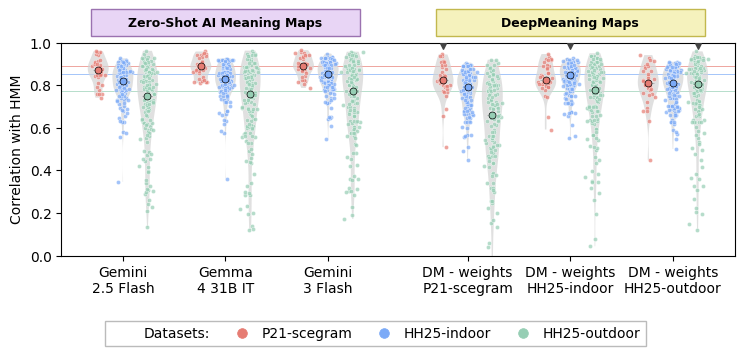

Saved -> results/paper_plots/fig2_model_comparison_violin.png
Figure size: 190.0 x 95.0 mm


In [9]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

def _draw_violin_panel(ax, models_list, data_dict, x_start=0.0,
                       inner_gap=0.30, group_sep=0.65):
    """Draw violin + jitter + median dots onto ax, starting at x_start.

    Groups with fewer available datasets get proportionally less x-axis space;
    violins are always centred within their group. Draws only the data (no axis
    cosmetics) so several panels can share one axis.
    Returns (group_centers, x_end, positions) where x_end is the right edge of
    the content and positions maps (model_sp, dataset) -> x coordinate.
    """
    avail_per_model = {
        model_sp: [
            ds for ds in DATASETS
            if data_dict[model_sp].get(ds) is not None and len(data_dict[model_sp][ds]) > 0
        ]
        for model_sp, _ in models_list
    }

    positions     = {}
    group_centers = []
    x_cursor      = x_start
    for model_sp, _ in models_list:
        avail   = avail_per_model[model_sp]
        n_avail = max(len(avail), 1)
        half_w  = (n_avail - 1) / 2 * inner_gap
        gc      = x_cursor + half_w
        group_centers.append(gc)
        for k, dataset in enumerate(avail):
            positions[(model_sp, dataset)] = gc + (k - (n_avail - 1) / 2) * inner_gap
        x_cursor = gc + half_w + group_sep

    valid_items = [
        (model_sp, ds, data_dict[model_sp][ds], positions[(model_sp, ds)])
        for model_sp, _ in models_list
        for ds in avail_per_model[model_sp]
    ]

    if valid_items:
        parts = ax.violinplot(
            [v for _, _, v, _ in valid_items],
            positions=[p for _, _, _, p in valid_items],
            widths=inner_gap * 0.85,
            showmeans=False,
            showmedians=True,
            showextrema=False,
        )
        for pc, (_, ds, _, _) in zip(parts["bodies"], valid_items):
            pc.set_facecolor("lightgray")
            pc.set_alpha(0.7)
        if "cmedians" in parts:
            parts["cmedians"].set_edgecolor("#A0A0A0")
            parts["cmedians"].set_linewidth(0.5)

        rng = np.random.default_rng(42)
        for ms, ds, vals, pos in valid_items:
            color = DATASET_COLORS[ds]
            xj    = rng.normal(pos, 0.04, len(vals))
            ax.scatter(xj, vals, color=color, alpha=0.7, s=DOT_INDIVIDUAL,
                       edgecolors="white", linewidth=0.35, zorder=3)
            ax.scatter([pos], [np.median(vals)], color=color, s=DOT_GROUP+3,
                       edgecolors="black", linewidth=0.5, zorder=5)

    x_end = x_cursor - group_sep   # right edge of the last group's content
    return group_centers, x_end, positions


# --- Layout: both blocks share one y-axis, separated by a wider gap and each
# labelled by a header box above. Width is fixed by FIG_WIDTH_MM. ------------
FIG2_HEIGHT_MM = 95.0        # tweak height freely; width is unaffected
SUPERGROUP_GAP = 1.10        # extra x-gap between the two blocks
INNER_GAP      = 0.30
GROUP_SEP      = 0.65
SHOW_SAMESET_MARKERS = True  # marker above each DeepMeaning same-set (train == test) violin

# Model whose per-dataset median is drawn as a reference line (set in config).
REFERENCE_MODEL = f"{fig2_model_slug}_{fig2_prompt_id}"

fig2_violin, ax = plt.subplots(
    1, 1, figsize=(FIG_WIDTH_IN, mm_to_in(FIG2_HEIGHT_MM)),
)

# --- Reference lines: median of REFERENCE_MODEL, one per dataset -------------
# Drawn first, behind everything, so each line passes through that model's
# plotted median dot for the dataset.
ref_data = fig2_vlm_data.get(REFERENCE_MODEL, {})
for ds in DATASETS:
    vals = ref_data.get(ds)
    if vals is not None and len(vals) > 0:
        ax.axhline(float(np.median(vals)), color=DATASET_COLORS[ds],
                   linewidth=0.6, linestyle="-", alpha=0.8, zorder=0.5)

# --- Draw both blocks on the shared axis -------------------------------------
gc_vlm, x_end_vlm, _ = _draw_violin_panel(
    ax, MODELS_FIG2_VLM, fig2_vlm_data,
    x_start=0.0, inner_gap=INNER_GAP, group_sep=GROUP_SEP,
)
gc_dmm, x_end_dmm, pos_dmm = _draw_violin_panel(
    ax, MODELS_FIG2_DMM, fig2_dmm_data,
    x_start=x_end_vlm + SUPERGROUP_GAP, inner_gap=INNER_GAP, group_sep=GROUP_SEP,
)

# --- Markers above the DeepMeaning same-set (train == test) violins ----------
# All at the same fixed height, just below the top axis line.
if SHOW_SAMESET_MARKERS:
    for trained_ds, _ in MODELS_FIG2_DMM:
        x = pos_dmm.get((trained_ds, trained_ds))
        vals = (fig2_dmm_data.get(trained_ds) or {}).get(trained_ds)
        if x is not None and vals is not None and len(vals) > 0:
            ax.scatter([x], [0.982], marker="v", s=16, color="#444444", zorder=6)

# --- Axis cosmetics ----------------------------------------------------------
group_centers = gc_vlm + gc_dmm
group_labels  = [lbl for _, lbl in MODELS_FIG2_VLM] + [lbl for _, lbl in MODELS_FIG2_DMM]
ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels)               # fontsize from rcParams
ax.set_ylim(0, 1)
ax.set_xlim(-0.45, x_end_dmm + 0.45)
ax.set_ylabel("Correlation with HMM")
ax.grid(False)                                 # replaced by the reference lines

# --- Block header boxes (coloured band + centred label above each block) -----
xtrans = ax.get_xaxis_transform()              # x in data coords, y in axes frac
BOX_Y0, BOX_H = 1.03, 0.125                    # axes fraction, above the axes
for centers, label, facecolor, edgecolor in [
    (gc_vlm, "Zero-Shot AI Meaning Maps", "#E8D5F5", "#9B72B0"),   # violet, matches Fig 1
    (gc_dmm, "DeepMeaning Maps",          "#F5F2BD", "#C2B84E"),   # yellow
]:
    x0, x1 = centers[0] - INNER_GAP * 1.3, centers[-1] + INNER_GAP * 1.3
    ax.add_patch(Rectangle(
        (x0, BOX_Y0), x1 - x0, BOX_H, transform=xtrans, clip_on=False,
        facecolor=facecolor, edgecolor=edgecolor, linewidth=1.0, zorder=6,
    ))
    ax.text((x0 + x1) / 2, BOX_Y0 + BOX_H / 2, label, transform=xtrans,
            ha="center", va="center", fontsize=BASE_FONTSIZE + 2,
            fontweight="bold", zorder=7)

# --- Horizontal legend below, prefixed "Datasets:" (circular swatches) --------
legend_handles = [Line2D([], [], linestyle="none", marker="", label="Datasets:")]
legend_handles += [
    Line2D([], [], linestyle="none", marker="o", markersize=7,
           markerfacecolor=DATASET_COLORS[ds], markeredgecolor=DATASET_COLORS[ds],
           markeredgewidth=0.5, label=DATASET_LABELS.get(ds, ds))
    for ds in DATASETS
]
fig2_violin.legend(
    handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 0.0),
    ncol=len(legend_handles), frameon=True, framealpha=1.0,
    edgecolor="#bbbbbb", fancybox=False, borderpad=0.4,
    handletextpad=0.4, columnspacing=1.3,
)

# Leave room above (header boxes) and below (tick labels + legend). Do NOT use
# tight_layout / bbox='tight': the saved width must stay exactly FIG_WIDTH_MM.
fig2_violin.subplots_adjust(left=0.08, right=0.98, top=0.83, bottom=0.26)

save_path_fig2_violin = os.path.join(publication_output, "fig2_model_comparison_violin.png")
fig2_violin.savefig(save_path_fig2_violin, dpi=500)
plt.show()

_w_in, _h_in = fig2_violin.get_size_inches()
print(f"Saved -> {save_path_fig2_violin}")
print(f"Figure size: {_w_in * MM_PER_INCH:.1f} x {_h_in * MM_PER_INCH:.1f} mm")

### Figure 2 — summary table

Mean Fisher-transformed r with 95% CI (r→z→r, CI from the t-distribution).
Rows are the VLMs, then one row per set of DM weights; columns are the dataset
the correlation is measured on (for DM rows, the dataset the maps were
*applied* to, so the matching column is the same-set result).

In [10]:
# --- Figure 2: mean [95% CI] (r→z→r) ----------------------------------------
col_tuples_fig2_trans = [('Mean [95% CI] (r→z→r)', DATASET_LABELS.get(ds, ds)) for ds in DATASETS]


def _fmt_mean_ci(vals):
    if vals is not None and len(vals) >= 2:
        mr, lo, hi = mean_r_ci(vals)
        return f'{mr:.2f} [{lo:.2f}, {hi:.2f}]'
    return '—'


records_fig2_trans = []

# Zero-shot VLMs: one value per dataset (all measured on that dataset)
for ms, label in MODELS_FIG2_VLM:
    row = [_fmt_mean_ci((fig2_vlm_data.get(ms) or {}).get(ds)) for ds in DATASETS]
    records_fig2_trans.append((label.replace("\n", " "), row))

# DeepMeaning: one row per training set; each column = applied dataset
for trained_ds, label in MODELS_FIG2_DMM:
    row = [_fmt_mean_ci((fig2_dmm_data.get(trained_ds) or {}).get(ds)) for ds in DATASETS]
    records_fig2_trans.append((label.replace("\n", " "), row))

idx_fig2_trans = pd.MultiIndex.from_tuples(col_tuples_fig2_trans, names=['Statistic', 'Dataset'])
df_fig2_trans = pd.DataFrame(
    [row for _, row in records_fig2_trans],
    index=[lbl for lbl, _ in records_fig2_trans],
    columns=idx_fig2_trans,
)
df_fig2_trans.index.name = 'Model'
display(clean_style(df_fig2_trans).format(na_rep='—'))

### Figure 2 — statistical comparisons

All tests run on Fisher z-transformed per-image Pearson r values. Entries are the
zero-shot VLMs plus one per DeepMeaning training set, so the full 3 × 3
train × test grid is covered. The `A type` / `B type` columns mark whether a DMM
entry is the same-set case for that dataset or cross-dataset transfer; they are
blank for VLMs. FDR correction (Benjamini-Hochberg) is applied within each table.

- **Table A** — models compared within each dataset. Wilcoxon signed-rank when
  both produce the same *n* images in the same order, otherwise Mann-Whitney U.
- **Table B** — datasets compared within each model (Mann-Whitney U).
- **Table C** — equality of variances across datasets (Fligner-Killeen), globally
  per model and pairwise.

In [11]:
from scipy import stats
from itertools import combinations


# DeepMeaning enters as one pseudo-model per training set, whose per-dataset
# arrays are the maps applied to that dataset. Every DMM row therefore spans the
# full 3x3 grid, with applied == trained as the same-set cell.
DM_TRAINED_ON = {f"dm_{trained}": trained for trained, _ in MODELS_FIG2_DMM}

dmm_train_data = {
    f"dm_{trained}": {ds: (fig2_dmm_data.get(trained) or {}).get(ds) for ds in DATASETS}
    for trained, _ in MODELS_FIG2_DMM
}


def _sameset_tag(ms, ds):
    """'same-set' if model `ms` was trained on `ds`, else 'cross' / '' for VLMs."""
    trained = DM_TRAINED_ON.get(ms)
    if trained is None:
        return ''
    return 'same-set' if trained == ds else 'cross'


_fig2_models_stats = [
    (ms, label.replace("\n", " "), fig2_vlm_data) for ms, label in MODELS_FIG2_VLM
] + [
    (f"dm_{trained}", label.replace("\n", " "), dmm_train_data)
    for trained, label in MODELS_FIG2_DMM
]

# --- Table A: pairwise model comparisons within each dataset ----------------
rows_A = []
for ds in DATASETS:
    ds_label = DATASET_LABELS.get(ds, ds)
    mods = [(ms, lbl, src_d) for ms, lbl, src_d in _fig2_models_stats
            if (src_d.get(ms) or {}).get(ds) is not None
            and len((src_d.get(ms) or {}).get(ds, [])) > 0]
    for (ms1, lbl1, src1), (ms2, lbl2, src2) in combinations(mods, 2):
        a = r2z(src1[ms1][ds])
        b = r2z(src2[ms2][ds])
        if len(a) == len(b):
            try:
                stat, p = stats.wilcoxon(a - b, alternative='two-sided')
                test = 'Wilcoxon'
            except ValueError:
                stat, p = float('nan'), float('nan')
                test = 'Wilcoxon(err)'
        else:
            stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
            test = 'Mann-Whitney'
        rows_A.append({
            'Dataset': ds_label, 'Model A': lbl1, 'Model B': lbl2,
            'A type': _sameset_tag(ms1, ds), 'B type': _sameset_tag(ms2, ds),
            'Test': test, 'n_A': len(a), 'n_B': len(b),
            'stat': f'{stat:.0f}', '_p': p,
        })

pA = fdr_bh([r['_p'] for r in rows_A])
for r, pa in zip(rows_A, pA):
    r['p'] = fmt_p(r['_p']); r['p_adj (BH)'] = fmt_p(pa); del r['_p']

df_A = pd.DataFrame(rows_A).set_index(['Dataset', 'Model A', 'Model B'])
print('Table A — pairwise model comparisons within each dataset (Fisher z-transformed r)')
display(clean_style(df_A))

# --- Table B: pairwise dataset comparisons within each model ----------------
# For DMM rows these are the datasets the maps were applied to.
rows_B = []
for ms, model_label, src_d in _fig2_models_stats:
    avail = [(ds, DATASET_LABELS.get(ds, ds)) for ds in DATASETS
             if (src_d.get(ms) or {}).get(ds) is not None
             and len((src_d.get(ms) or {}).get(ds, [])) > 0]
    for (ds1, lbl1), (ds2, lbl2) in combinations(avail, 2):
        a = r2z(src_d[ms][ds1])
        b = r2z(src_d[ms][ds2])
        stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        rows_B.append({
            'Model': model_label, 'Dataset A': lbl1, 'Dataset B': lbl2,
            'A type': _sameset_tag(ms, ds1), 'B type': _sameset_tag(ms, ds2),
            'n_A': len(a), 'n_B': len(b), 'U': f'{stat:.0f}', '_p': p,
        })

pB = fdr_bh([r['_p'] for r in rows_B])
for r, pb in zip(rows_B, pB):
    r['p'] = fmt_p(r['_p']); r['p_adj (BH)'] = fmt_p(pb); del r['_p']

df_B = pd.DataFrame(rows_B).set_index(['Model', 'Dataset A', 'Dataset B'])
print('\nTable B — pairwise dataset comparisons within each model (Mann-Whitney U)')
display(clean_style(df_B))

# --- Table C: variance equality across datasets (Fligner-Killeen) -----------
rows_Cg, rows_Cp = [], []
for ms, model_label, src_d in _fig2_models_stats:
    grps = [
        (ds, DATASET_LABELS.get(ds, ds), r2z((src_d.get(ms) or {}).get(ds, np.array([]))))
        for ds in DATASETS
        if (src_d.get(ms) or {}).get(ds) is not None
        and len((src_d.get(ms) or {}).get(ds, [])) >= 2
    ]
    if len(grps) >= 2:
        stat_g, p_g = stats.fligner(*[arr for _, _, arr in grps])
        rows_Cg.append({
            'Model': model_label,
            'Groups': ' vs '.join(lbl for _, lbl, _ in grps),
            'stat': f'{stat_g:.3f}', 'p': fmt_p(p_g),
        })
        for (ds1, lbl1, a), (ds2, lbl2, b) in combinations(grps, 2):
            stat_p, p_p = stats.fligner(a, b)
            rows_Cp.append({
                'Model': model_label, 'Dataset A': lbl1, 'Dataset B': lbl2,
                'A type': _sameset_tag(ms, ds1), 'B type': _sameset_tag(ms, ds2),
                'stat': f'{stat_p:.3f}', '_p': p_p,
            })

pC = fdr_bh([r['_p'] for r in rows_Cp])
for r, pc_adj in zip(rows_Cp, pC):
    r['p'] = fmt_p(r['_p']); r['p_adj (BH)'] = fmt_p(pc_adj); del r['_p']

df_Cg = pd.DataFrame(rows_Cg).set_index('Model')
df_Cp = pd.DataFrame(rows_Cp).set_index(['Model', 'Dataset A', 'Dataset B'])

print('\nTable C — Fligner-Killeen, all datasets jointly per model')
display(clean_style(df_Cg))
print('\nTable C (pairwise) — Fligner-Killeen for each pair of datasets within each model')
display(clean_style(df_Cp))

Table A — pairwise model comparisons within each dataset (Fisher z-transformed r)



Table B — pairwise dataset comparisons within each model (Mann-Whitney U)



Table C — Fligner-Killeen, all datasets jointly per model


,Groups,stat,p
Model,,,
Gemini 2.5 Flash,P21-scegram vs HH25-indoor vs HH25-outdoor,33.605,< 0.0001
Gemma 4 31B IT,P21-scegram vs HH25-indoor vs HH25-outdoor,39.613,< 0.0001
Gemini 3 Flash,P21-scegram vs HH25-indoor vs HH25-outdoor,44.062,< 0.0001
DM - weights P21-scegram,P21-scegram vs HH25-indoor vs HH25-outdoor,30.790,< 0.0001
DM - weights HH25-indoor,P21-scegram vs HH25-indoor vs HH25-outdoor,32.473,< 0.0001
DM - weights HH25-outdoor,P21-scegram vs HH25-indoor vs HH25-outdoor,27.020,< 0.0001



Table C (pairwise) — Fligner-Killeen for each pair of datasets within each model


### DM weight variants vs Gemini 3 Flash

Every pair among the three sets of DM weights and Gemini 3 Flash, compared on
each dataset. On a given dataset the weights trained on it are the same-set case
and the other two are transfer. BH-FDR applied across the whole table.

In [12]:
# Each set of DM weights is wrapped so that the key "m" maps to its
# {applied_dataset: correlations} dict, matching the VLM entries' shape.
_dmm_train_srcs = {
    trained: {"m": {ds: (fig2_dmm_data.get(trained) or {}).get(ds) for ds in DATASETS}}
    for trained, _ in MODELS_FIG2_DMM
}

_extra_models = [
    ("m", label.replace("\n", " "), _dmm_train_srcs[trained])
    for trained, label in MODELS_FIG2_DMM
] + [
    ("gemini-3-flash-preview_original", "Gemini 3 Flash", fig2_vlm_data),
]

rows_extra = []
for (ms1, lbl1, src1), (ms2, lbl2, src2) in combinations(_extra_models, 2):
    for ds in DATASETS:
        arr1 = (src1.get(ms1) or {}).get(ds)
        arr2 = (src2.get(ms2) or {}).get(ds)
        if arr1 is None or arr2 is None or len(arr1) == 0 or len(arr2) == 0:
            continue
        a, b = r2z(arr1), r2z(arr2)
        if len(a) == len(b):
            try:
                stat, p = stats.wilcoxon(a - b, alternative='two-sided')
                test = 'Wilcoxon'
            except ValueError:
                stat, p = float('nan'), float('nan')
                test = 'Wilcoxon(err)'
        else:
            stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
            test = 'Mann-Whitney'
        rows_extra.append({
            'Dataset': DATASET_LABELS.get(ds, ds),
            'Model A': lbl1,
            'Model B': lbl2,
            'Test': test,
            'n_A': len(a), 'n_B': len(b),
            'stat': f'{stat:.0f}', '_p': p,
        })

if rows_extra:
    p_extra = fdr_bh([r['_p'] for r in rows_extra])
    for r, pa in zip(rows_extra, p_extra):
        r['p'] = fmt_p(r['_p']); r['p_adj (BH)'] = fmt_p(pa); del r['_p']
    df_extra = pd.DataFrame(rows_extra).set_index(['Dataset', 'Model A', 'Model B'])
    print("DM weight variants × Gemini 3 Flash (Fisher z-transformed r)")
    display(clean_style(df_extra))
else:
    print("No overlapping dataset/model combinations found.")

DM weight variants × Gemini 3 Flash (Fisher z-transformed r)


,,,Test,n_A,n_B,stat,p,p_adj (BH)
Dataset,Model A,Model B,,,,,,
P21-scegram,DM - weights P21-scegram,DM - weights HH25-indoor,Wilcoxon,36,36,286,0.4697,0.4973
HH25-indoor,DM - weights P21-scegram,DM - weights HH25-indoor,Wilcoxon,140,140,30,< 0.0001,< 0.0001
HH25-outdoor,DM - weights P21-scegram,DM - weights HH25-indoor,Wilcoxon,142,142,438,< 0.0001,< 0.0001
P21-scegram,DM - weights P21-scegram,DM - weights HH25-outdoor,Wilcoxon,36,36,211,0.0556,0.0625
HH25-indoor,DM - weights P21-scegram,DM - weights HH25-outdoor,Wilcoxon,140,140,2900,< 0.0001,< 0.0001
HH25-outdoor,DM - weights P21-scegram,DM - weights HH25-outdoor,Wilcoxon,142,142,286,< 0.0001,< 0.0001
P21-scegram,DM - weights P21-scegram,Gemini 3 Flash,Wilcoxon,36,36,25,< 0.0001,< 0.0001
HH25-indoor,DM - weights P21-scegram,Gemini 3 Flash,Wilcoxon,140,140,91,< 0.0001,< 0.0001
HH25-outdoor,DM - weights P21-scegram,Gemini 3 Flash,Wilcoxon,142,142,738,< 0.0001,< 0.0001


## Figure 3 — Correlation with fixations

Loads six maps per dataset (fixation, AIMM, HMM, DMM, GBVS, AWS, DGIIE) in the
center-bias condition set by `DATASET_BIAS`: AIMM comes from
`maps_combined_raw/` for `ncb` and `maps_combined_cb/` for `cb`. DMM is always
the same-set DeepMeaning map (trained and tested on the same dataset).

Computed **with smoothing** (`FIG3_SMOOTHING_SIGMA = 15`, excluding `fixation`,
`gbvs`, `aws`, `deepgaze`) — unlike Figure 2.

In [13]:
# AIMM subdirectory depends on the bias condition.
AI_SUBDIR = {
    "ncb": "maps_combined_raw/",
    "cb":  "maps_combined_cb/",
}

plotter_fig3 = MultiDatasetPlotter()

for dataset in DATASETS:
    bias       = DATASET_BIAS[dataset]
    output_dir = f"results/results_maps/{dataset}/{fig3_model_slug_and_prompt}"

    # DeepMeaning same-set (trained == tested here). Always the raw maps; no cb
    # variant is produced.
    dmm_dir = os.path.join(
        DEEPMEANING_ROOT,
        f"{DM_DATASET_TOKEN[dataset]}__to__{DM_DATASET_TOKEN[dataset]}",
        "maps_combined_raw",
    )

    select_maps = {
        "fixation": f"data/{dataset}/maps/fixation",
        "aimm":     os.path.join(output_dir, AI_SUBDIR[bias]),
        "mm":       f"data/{dataset}/maps/meaning_{bias}",
        "dmm":      dmm_dir,
        "gbvs":     f"data/{dataset}/maps/gbvs_{bias}",
        "aws":      f"data/{dataset}/maps/aws_{bias}",
        "deepgaze": f"data/{dataset}/maps/deepgaze_{bias}",
    }

    # Skip directories that don't exist yet
    select_maps = {k: v for k, v in select_maps.items() if os.path.isdir(v)}
    missing = {"fixation", "aimm", "mm", "dmm", "gbvs", "aws", "deepgaze"} - set(select_maps)
    if missing:
        print(f"  {dataset} [{bias}]: missing maps will show as N/A — {missing}")

    comparator = SaliencyComparator(
        image_dir=f"data/{dataset}/images",
        map_configs=select_maps,
    )
    comparator.load_data()
    comparator.compute_correlations(
        histogram_match=HISTOGRAM_MATCH,
        histogram_reference=MATCHING_REFERENCE,
        aggregation_method="median",
        smoothing_sigma=FIG3_SMOOTHING_SIGMA,
        exclude_from_smoothing=FIG3_EXCLUDE_FROM_SMOOTHING,
        exclude_from_matching=EXCLUDE_FROM_MATCHING,
    )

    plotter_fig3.add_dataset(
        name=dataset,
        comparator=comparator,
        color=DATASET_COLORS[dataset],
        label=DATASET_LABELS.get(dataset, dataset),
    )
    print(f"  {dataset} [{bias}]: {len(comparator.all_correlations)} images, maps: {list(select_maps.keys())}")

print("\nFigure 3 data ready.")

SaliencyComparator initialized successfully
Image directory: data/P21_scegram/images
Map types: ['fixation', 'aimm', 'mm', 'dmm', 'gbvs', 'aws', 'deepgaze']
Loading 36 common images...


Successfully loaded data for 36 images
Data loaded for 36 images
Computing pearson correlations with histogram_match=False, aggregation=median...
Applying Gaussian smoothing (sigma=15) before correlation, excluding ['fixation', 'gbvs', 'aws', 'deepgaze']


Correlations computed for 36 images using median
  P21_scegram [ncb]: 36 images, maps: ['fixation', 'aimm', 'mm', 'dmm', 'gbvs', 'aws', 'deepgaze']
SaliencyComparator initialized successfully
Image directory: data/HH25_indoor/images
Map types: ['fixation', 'aimm', 'mm', 'dmm', 'gbvs', 'aws', 'deepgaze']
Loading 51 common images...


Successfully loaded data for 51 images
Data loaded for 51 images
Computing pearson correlations with histogram_match=False, aggregation=median...
Applying Gaussian smoothing (sigma=15) before correlation, excluding ['fixation', 'gbvs', 'aws', 'deepgaze']


Correlations computed for 51 images using median
  HH25_indoor [ncb]: 51 images, maps: ['fixation', 'aimm', 'mm', 'dmm', 'gbvs', 'aws', 'deepgaze']
SaliencyComparator initialized successfully
Image directory: data/HH25_outdoor/images
Map types: ['fixation', 'aimm', 'mm', 'dmm', 'gbvs', 'aws', 'deepgaze']
Loading 49 common images...


Successfully loaded data for 49 images
Data loaded for 49 images
Computing pearson correlations with histogram_match=False, aggregation=median...
Applying Gaussian smoothing (sigma=15) before correlation, excluding ['fixation', 'gbvs', 'aws', 'deepgaze']


Correlations computed for 49 images using median
  HH25_outdoor [ncb]: 49 images, maps: ['fixation', 'aimm', 'mm', 'dmm', 'gbvs', 'aws', 'deepgaze']

Figure 3 data ready.


### Panel A — statistics

Correlation with fixations per map. Rows are datasets, columns are maps; each
cell is mean [95% CI] from Fisher r→z→r.

In [14]:
# --- Figure 3, panel A: correlation with fixations, per map -----------------
PANEL_A_MAPS = ['aimm', 'mm', 'dmm', 'gbvs', 'aws', 'deepgaze']
MAP_DISPLAY  = {'aimm': 'AIMM', 'mm': 'HMM', 'dmm': 'DMM',
                'gbvs': 'GBVS', 'aws': 'AWS', 'deepgaze': 'DGIIE'}

records_a_trans = []
for ds in DATASETS:
    row = {}
    for m in PANEL_A_MAPS:
        vals = plotter_fig3._get_correlation_values(ds, 'fixation', m)
        disp = MAP_DISPLAY[m]
        if len(vals) >= 2:
            mr, lo, hi = mean_r_ci(vals)
            row[disp] = f'{mr:.2f} [{lo:.2f}, {hi:.2f}]'
        elif len(vals) == 1:
            row[disp] = f'{float(np.mean(vals)):.2f}'
        else:
            row[disp] = 'N/A'
    records_a_trans.append(row)

df_fig3a_trans = pd.DataFrame(records_a_trans, index=[DATASET_LABELS.get(ds, ds) for ds in DATASETS])
df_fig3a_trans.index.name = 'Dataset'
display(clean_style(df_fig3a_trans))

,AIMM,HMM,DMM,GBVS,AWS,DGIIE
Dataset,,,,,,
P21-scegram,"0.69 [0.67, 0.71]","0.68 [0.66, 0.70]","0.65 [0.62, 0.67]","0.62 [0.57, 0.66]","0.71 [0.67, 0.75]","0.76 [0.74, 0.78]"
HH25-indoor,"0.61 [0.58, 0.63]","0.62 [0.60, 0.64]","0.64 [0.61, 0.66]","0.56 [0.53, 0.60]","0.59 [0.55, 0.62]","0.73 [0.71, 0.75]"
HH25-outdoor,"0.60 [0.56, 0.63]","0.57 [0.53, 0.61]","0.60 [0.55, 0.64]","0.62 [0.58, 0.66]","0.52 [0.45, 0.59]","0.72 [0.69, 0.74]"


### Panels B & C — statistics

Computed here so the annotations printed on the scatter panels match these tables
exactly. All analyses use Fisher z-transformed first-order correlations.

- **Correlation** — Pearson r between the two maps' per-image fixation-correlation
  vectors.
- **Difference** — mean z(x) − z(y); positive means the x-axis map predicts
  fixations better. Tested with a paired Wilcoxon signed-rank test.

In [15]:
# --- Figure 3, panels B & C: second-order correlations + Wilcoxon tests -----
_COL_MI_B = pd.MultiIndex.from_tuples([
    ('', 'n'),
    ('Corr. AIMM vs Fix / HMM vs Fix', 'r'),
    ('Corr. AIMM vs Fix / HMM vs Fix', '95% CI'),
    ('Corr. AIMM vs Fix / HMM vs Fix', 'p'),
    ('Diff. AIMM vs Fix / HMM vs Fix', 'mean diff.'),
    ('Diff. AIMM vs Fix / HMM vs Fix', '95% CI'),
    ('Diff. AIMM vs Fix / HMM vs Fix', 'z'),
    ('Diff. AIMM vs Fix / HMM vs Fix', 'p'),
])

_COL_MI_C = pd.MultiIndex.from_tuples([
    ('', 'n'),
    ('Corr. Y-map vs Fix / X-map vs Fix', 'r'),
    ('Corr. Y-map vs Fix / X-map vs Fix', '95% CI'),
    ('Corr. Y-map vs Fix / X-map vs Fix', 'p'),
    ('Diff. Y-map vs Fix / X-map vs Fix', 'mean diff.'),
    ('Diff. Y-map vs Fix / X-map vs Fix', '95% CI'),
    ('Diff. Y-map vs Fix / X-map vs Fix', 'z'),
    ('Diff. Y-map vs Fix / X-map vs Fix', 'p'),
])

_MAP_DISP = {'aimm': 'AIMM', 'mm': 'HMM', 'dmm': 'DMM', 'gbvs': 'GBVS', 'aws': 'AWS', 'deepgaze': 'DGIIE'}
_RAW_KEYS = ['_r', '_W', '_z', '_p_r', '_p_W']

# Panel C y-axis maps: DMM sits alongside the saliency models and is compared
# against both the AIMM and HMM references.
PANEL_C_SAL_MAPS = ['dmm', 'gbvs', 'aws', 'deepgaze']

# --- Panel B: x = corr(AIMM, fixations), y = corr(HMM, fixations) ---------
print("Panel B — x-axis: corr(AIMM, Fixation), y-axis: corr(HMM, Fixation)")
print("Difference = mean z(x) − z(y); positive means AIMM predicts fixations better\n")

rows_b = []
stats_b_plot = {}

for ds in DATASETS:
    comp = plotter_fig3._datasets[ds]['comparator']
    x_r, y_r = [], []
    for corr_df in comp.all_correlations.values():
        xv = plotter_fig3._safe_corr(corr_df, 'fixation', 'aimm')
        yv = plotter_fig3._safe_corr(corr_df, 'fixation', 'mm')
        if not (np.isnan(xv) or np.isnan(yv)):
            x_r.append(xv); y_r.append(yv)
    result = second_order_stats(np.array(x_r), np.array(y_r))
    rows_b.append({'Dataset': DATASET_LABELS.get(ds, ds), **result})
    stats_b_plot[ds] = {'r': result['_r'], 'z': result['_z'], 'p_r': result['_p_r'], 'p_W': result['_p_W']}

df_fig3b = pd.DataFrame(rows_b).set_index('Dataset').drop(columns=_RAW_KEYS)
df_fig3b.columns = _COL_MI_B
display(clean_style(df_fig3b))

# --- Panel C: x = corr(ref_map, fixations), y = corr(sal_map, fixations) ----
print("\nPanel C — x-axis: corr(AIMM or HMM, Fixation), y-axis: corr(DMM/saliency map, Fixation)")
print("Difference = mean z(x) − z(y); positive means AIMM / HMM predicts fixations better\n")

rows_c = []
stats_c_plot = {}

for ds in DATASETS:
    comp = plotter_fig3._datasets[ds]['comparator']
    for ref_m in ['aimm', 'mm']:
        for sal_m in PANEL_C_SAL_MAPS:
            x_r, y_r = [], []
            for corr_df in comp.all_correlations.values():
                xv = plotter_fig3._safe_corr(corr_df, 'fixation', ref_m)
                yv = plotter_fig3._safe_corr(corr_df, 'fixation', sal_m)
                if not (np.isnan(xv) or np.isnan(yv)):
                    x_r.append(xv); y_r.append(yv)
            if len(x_r) >= 4:
                result = second_order_stats(np.array(x_r), np.array(y_r))
                rows_c.append({
                    'Dataset': DATASET_LABELS.get(ds, ds),
                    'Y-map': _MAP_DISP.get(ref_m, ref_m),
                    'X-map': _MAP_DISP.get(sal_m, sal_m),
                    **result,
                })
                stats_c_plot[(ds, ref_m, sal_m)] = {
                    'r': result['_r'], 'z': result['_z'],
                    'p_r': result['_p_r'], 'p_W': result['_p_W'],
                }

df_fig3c = pd.DataFrame(rows_c).set_index(['Dataset', 'Y-map', 'X-map']).drop(columns=_RAW_KEYS)
df_fig3c.columns = _COL_MI_C
display(clean_style(df_fig3c))

Panel B — x-axis: corr(AIMM, Fixation), y-axis: corr(HMM, Fixation)
Difference = mean z(x) − z(y); positive means AIMM predicts fixations better




Panel C — x-axis: corr(AIMM or HMM, Fixation), y-axis: corr(DMM/saliency map, Fixation)
Difference = mean z(x) − z(y); positive means AIMM / HMM predicts fixations better



### Assembled figure

One block per dataset, split into two stacked sub-rows so the DMM column fits the
fixed journal width.

**Top sub-row** — **A** violin + dots: correlation with fixations for each map
(AIMM, HMM, DMM, GBVS, AWS, DGIIE) · **B** scatter of corr(AIMM, fix) against
corr(HMM, fix), one dot per image, with identity line.

**Bottom sub-row** — **C** a 2 × 4 scatter grid: AIMM (row 1) and HMM (row 2)
each against DMM, GBVS, AWS and DGIIE, all measured via fixation correlation.

[fig3 layout] figure        : 121.0 x 269.0 mm
[fig3 layout] block height  : 74.5 mm (A/B 30.5 + gap 9.0 + C 35.0)
[fig3 layout] panel A       : 57.0 x 30.5 mm
[fig3 layout] panel B square: 28.0 mm (cell 28.0 x 30.5)
[fig3 layout] C square      : 16.0 mm (cell 16.0 x 16.0, width-limited); visual x-gap 12.0 mm


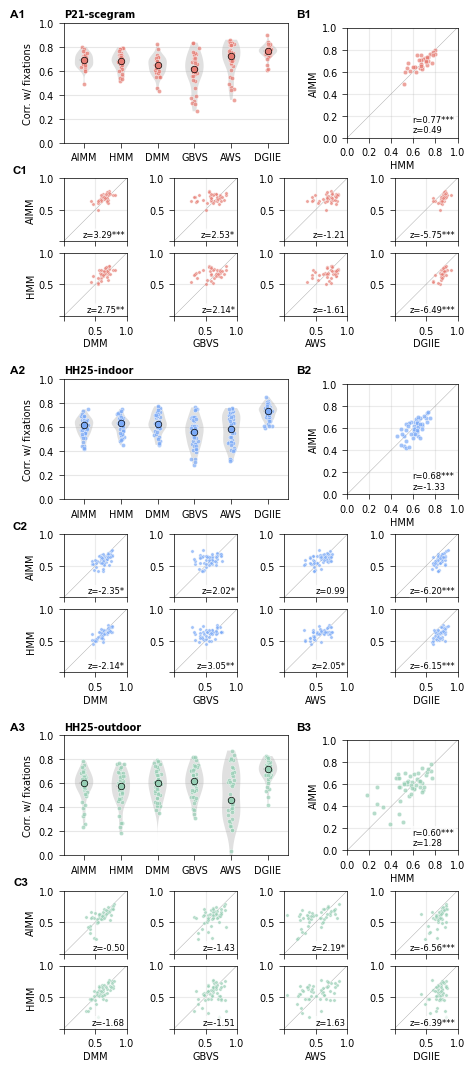

Figure 3 size: 121.0 x 269.0 mm


In [16]:
# --- Figure 3 geometry (all in mm) ------------------------------------------
# Panels B and C are aspect='equal' squares, so the figure width is a consequence
# of the panel sizes rather than a free knob: stretched to the full 190 mm the C
# squares stay height-limited and drift apart, leaving large horizontal gaps.
# Instead the C square size is set directly, the leftover width goes into the
# column gaps (wide enough for y tick labels on every column), and the height is
# derived so the total stays <= 270 mm.
#
# The A/B/C letters sit beside their panels on the dataset label's baseline, so
# they cost no vertical space, but they need ~13 mm of clearance in margins_mm[0]
# (A and C) and in ab_gap_mm (B). Their offset is LETTER_DX_MM / LETTER_DY_MM in
# src/paper_plots.py.
FIG3_MARGINS_MM   = (16.0, 5.0, 8.5, 5.0)   # left, right, bottom, top
FIG3_WIDTH_MM     = 121.0                   # <= FIG_WIDTH_MM (journal maximum)
FIG3_C_SIDE_MM    = 16.0                    # side of the small C correlation panels
FIG3_C_GAP_Y_MM   = 3.0                     # vertical gap inside the C grid
FIG3_AB_HEIGHT_MM = 30.5                    # height of the A+B sub-row
FIG3_B_WIDTH_MM   = 28.0                    # panel B cell width (A takes the rest)
FIG3_BLOCK_GAP_MM = 16.0                    # C grid -> next dataset's A/B sub-row
FIG3_AB_C_GAP_MM  = 9.0                     # A/B sub-row -> C grid
FIG3_AB_GAP_MM    = 15.0                    # panel A -> panel B (holds the B letter)

FIG3_SAL_MAPS = ["dmm", "gbvs", "aws", "deepgaze"]
n_ds  = len(DATASETS)
n_sal = len(FIG3_SAL_MAPS)

_usable_w  = FIG3_WIDTH_MM - FIG3_MARGINS_MM[0] - FIG3_MARGINS_MM[1]
_c_gap_x   = (_usable_w - n_sal * FIG3_C_SIDE_MM) / (n_sal - 1)
_block_h   = (FIG3_AB_HEIGHT_MM + FIG3_AB_C_GAP_MM
              + 2 * FIG3_C_SIDE_MM + FIG3_C_GAP_Y_MM)
FIG3_HEIGHT_MM = (n_ds * _block_h + (n_ds - 1) * FIG3_BLOCK_GAP_MM
                  + FIG3_MARGINS_MM[2] + FIG3_MARGINS_MM[3])
assert _c_gap_x >= 6.0, f"C columns only {_c_gap_x:.1f} mm apart — no room for y tick labels"
assert min(FIG3_MARGINS_MM[0], FIG3_AB_GAP_MM) >= 13.0, "no room for the inline panel letters"
assert FIG3_HEIGHT_MM <= 270.0, f"Figure 3 is {FIG3_HEIGHT_MM:.1f} mm tall (max 270)"

# Fig 3 gets slightly thinner axes/tick lines than the rcParams default (0.8pt).
with plt.rc_context({
    "axes.linewidth":     0.5,
    "xtick.major.width":  0.5,
    "ytick.major.width":  0.5,
}):
    fig3 = plotter_fig3.plot_fixation_correlation_grid(
        fixation_map="fixation",
        test_map="aimm",
        mm_map="mm",
        saliency_maps=FIG3_SAL_MAPS,
        map_labels={
            "fixation":  "Fixations",
            "aimm":      "AIMM",
            "mm":        "HMM",
            "dmm":       "DMM",
            "gbvs":      "GBVS",
            "aws":       "AWS",
            "deepgaze":  "DGIIE",
        },
        central_tendency="median",
        show_stats_b=True,
        show_stats_c=True,                       # z values (no r) on the C panels
        stats_b=stats_b_plot,
        stats_c=stats_c_plot,
        figsize=(mm_to_in(FIG3_WIDTH_MM), mm_to_in(FIG3_HEIGHT_MM)),
        base_fontsize=BASE_FONTSIZE,              # figure is narrower than Fig 2
        tight_bbox=False,                         # keep the saved width exact
        dot_individual=DOT_INDIVIDUAL,            # dot sizes shared with Fig 2
        dot_group=DOT_GROUP,
        dot_scatter=DOT_SCATTER,
        dot_scatter_small=DOT_SCATTER_SMALL,
        ab_height_mm=FIG3_AB_HEIGHT_MM,
        b_width_mm=FIG3_B_WIDTH_MM,
        margins_mm=FIG3_MARGINS_MM,
        block_gap_mm=FIG3_BLOCK_GAP_MM,
        ab_c_gap_mm=FIG3_AB_C_GAP_MM,
        ab_gap_mm=FIG3_AB_GAP_MM,
        c_gap_mm=(_c_gap_x, FIG3_C_GAP_Y_MM),
        c_all_yticklabels=True,                   # y ticks on every C column
        letters_inline=True,                      # letters beside, not above, the panels
        violin_xlabel=None,                       # tick labels already name the maps
        violin_ylabel="Corr. w/ fixations",       # must fit inside FIG3_AB_HEIGHT_MM
        verbose_layout=True,
        dpi=500,
        save_path=os.path.join(publication_output, f"fig3_fixation_correlations_{fig3_model_slug}.png"),
    )
plt.show()

_w_in, _h_in = fig3.get_size_inches()
print(f"Figure 3 size: {_w_in * MM_PER_INCH:.1f} x {_h_in * MM_PER_INCH:.1f} mm")